In [1]:
pip install matplotlib scikit-learn numpy gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 63.5 MB/s eta 0:00:00


Loading models...
Saved: word_clusters_comparison.png


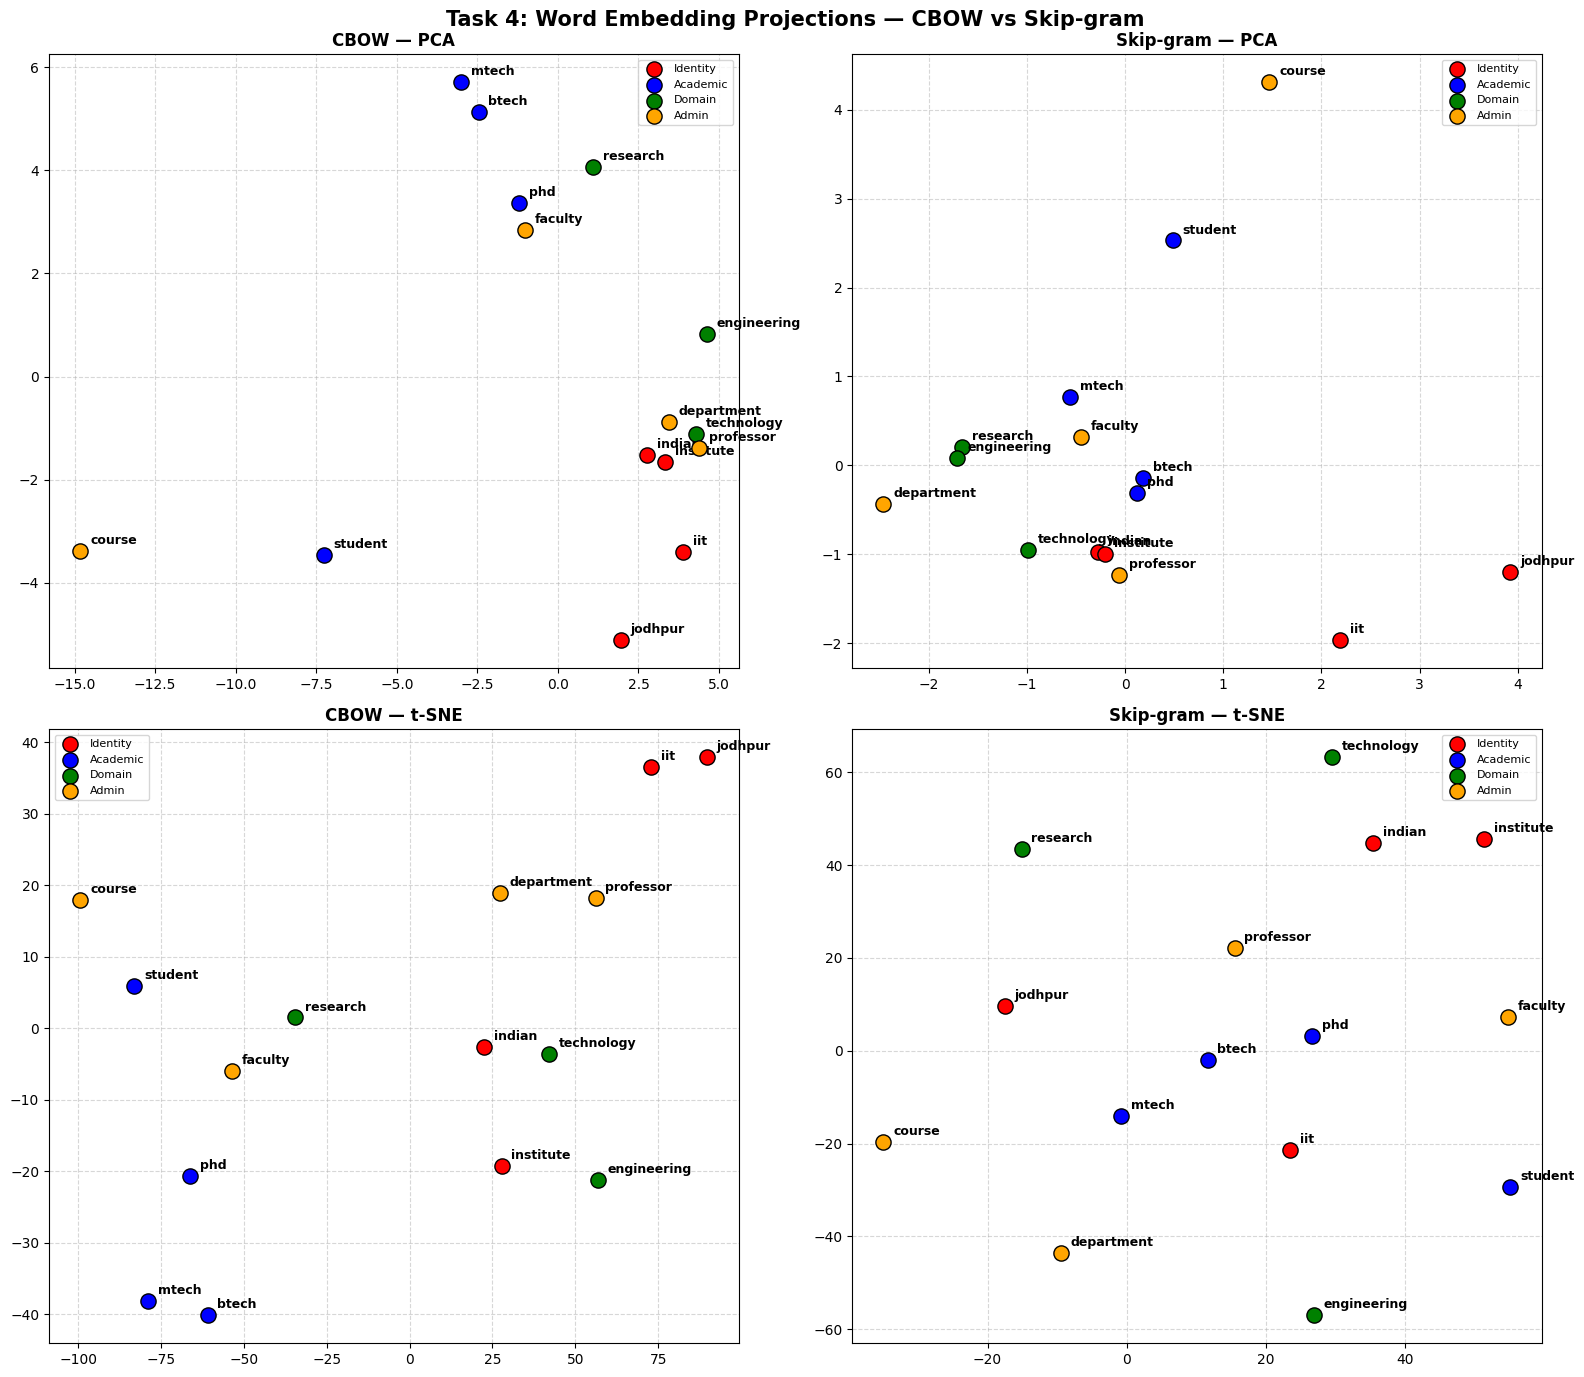

In [3]:
# ============================================================
# This loads the two Word2Vec models that were stored in Task 2,
# then projects its high-dimensional word vectors to 2D
# that we can visually examine how well using PCA and t-SNE
# related words form clusters.
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from sklearn.decomposition import PCA       # Dimensional reduction in a linear manner
from sklearn.manifold import TSNE           # Dimensionality reduction in Non-linear manner


# ------------------------------------------------------------
# HELPER FUNCTION: Embeddings of Projects and Plots of a single Model
# ------------------------------------------------------------
def plot_embeddings(model, title, ax, method='pca'):
    """
    Includes a trained Word2Vec model, projects its word vectors to 2D,
    and codes them in colour by category on the axes provided

    Args:
        model  : Trained Gensim Word2Vec model
        title  : title of the chart displayed above the subplot
        ax     : axes on which to draw
        method : 'pca' for linear reduction, 'tsne' for non-linear
    """

    # Name word groups based on semantic theme - these are represent
    # vocabulary used in an IIT Jodhpur setting
    clusters = {
        'Identity': ['iit', 'jodhpur', 'indian', 'institute'],  # Institution names
        'Academic': ['btech', 'mtech', 'phd', 'student'],       # Degree/student types
        'Domain':   ['research', 'technology', 'engineering'],   # Subject areas
        'Admin':    ['faculty', 'professor', 'department', 'course']  # Admin/teaching roles
    }

    # Groups can be visualised easily as each cluster is assigned a different colour
    colors = {
        'Identity': 'red',
        'Academic': 'blue',
        'Domain':   'green',
        'Admin':    'orange'
    }

    # Vet out words not included in the vocabulary of the model
    # (e.g., words that were used less often than min_count during training)
    valid = {
        cluster: [w for w in words if w in model.wv]
        for cluster, words in clusters.items()
    }

    # Map all the valid words in one ordered list to extract vectors
    all_words = [w for words in valid.values() for w in words]

    # To have any significant 2D projection we require at least 3 points
    if len(all_words) < 3:
        ax.set_title(f"{title}\n(insufficient vocab)")
        return

    # Recall the embedding vectors of all words - shape: (n_words, vector_size)
    vectors = np.array([model.wv[w] for w in all_words])

    # --- Dimensionality Reduction: vector_size creates a 2D version of vectorsize ---
    if method == 'pca':
        # PCA is very rapid and deterministic; suitable in identifying linear structure
        reducer = PCA(n_components=2)
        reduced = reducer.fit_transform(vectors)

    else:  # t-SNE
        # t-SNE does not lose local neighbourhood structure in comparison to PCA but perplexity should be.
        perplexity = min(5, len(all_words) - 1)
        reducer = TSNE(
            n_components=2,
            random_state=42,       # Fix seed such that the layout can be replicated
            perplexity=perplexity
        )
        reduced = reducer.fit_transform(vectors)

    # --- Plot all the semantic clusters with their colours ---
    idx = 0  # Follows us in the flattened all_words list
    for cluster, words in valid.items():
        if not words:
            continue  # Filter empty clusters (filter all words)

        n = len(words)
        pts = reduced[idx:idx + n]  # Split the 2-dimensional coords of this cluster

        # Plot scatter points -- edgecolors=black will create a thin frame around it
        ax.scatter(
            pts[:, 0], pts[:, 1],
            c=colors[cluster],
            s=120,
            edgecolors='black',
            label=cluster,
            zorder=3            # Make marks over grid lines
        )

        # Label the points by the words they signify
        for i, word in enumerate(words):
            ax.annotate(
                word,
                xy=(pts[i, 0], pts[i, 1]),
                xytext=(7, 5),               # None of the text should overlap the dot, so offset it
                textcoords='offset points',
                fontsize=9,
                fontweight='bold'
            )

        idx += n  # Move the index beyond the words we have just plotted

    # Final subplot styling
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.5)  # Light grid to read


# ------------------------------------------------------------
# MAIN VISUALIZATION FUNCTION
# ------------------------------------------------------------
def run_task_4_visualization():
    """
    The Skip-gram and CBOW models are loaded, obtained by Task 2,
    then forms a 2x2 comparison grid:


        Row 1 — PCA projections  : CBOW (left)  | Skip-gram (right)
        Row 2 — t-SNE projections: CBOW (left)  | Skip-gram (right)

    The last one is stored as a PNG and shown on the page.
    """

    sg_path   = "iitj_skipgram.model"
    cbow_path = "iitj_cbow.model"

    # Before attempting to load model files, verify that both exist -
    # instead of a cryptic FileNotFoundError, provides a useful message
    missing = [p for p in [sg_path, cbow_path] if not os.path.exists(p)]
    if missing:
        print(f"Missing model files: {missing}")
        print("Make sure Task 2 saves both 'iitj_skipgram.model' and 'iitj_cbow.model'")
        return

    print("Loading models...")
    sg_model   = Word2Vec.load(sg_path)
    cbow_model = Word2Vec.load(cbow_path)

    #Draw a grid of 2 rows x 2 columns subplot
    # figsize=(16, 14) provides sufficient space to add annotations to each subplot
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    fig.suptitle(
        "Task 4: Word Embedding Projections — CBOW vs Skip-gram",
        fontsize=15,
        fontweight='bold'
    )

    # Fill each subplot: row 0 = PCA, row 1 = t-SNE
    #                    col 0 = CBOW, col 1 = Skip-gram
    plot_embeddings(cbow_model, "CBOW — PCA",        axes[0][0], method='pca')
    plot_embeddings(sg_model,   "Skip-gram — PCA",   axes[0][1], method='pca')
    plot_embeddings(cbow_model, "CBOW — t-SNE",      axes[1][0], method='tsne')
    plot_embeddings(sg_model,   "Skip-gram — t-SNE", axes[1][1], method='tsne')

    # DO NOT overlap subplot titles/labels
    plt.tight_layout()

    # Save figure to disk with high resolution to submit
    plt.savefig("word_clusters_comparison.png", dpi=150, bbox_inches='tight')
    print("Saved: word_clusters_comparison.png")

    # Plot the output cell of the figure in the notebook
    plt.show()


# ------------------------------------------------------------
# ENTRY POINT
# ------------------------------------------------------------
if __name__ == "__main__":
    run_task_4_visualization()